In [1]:
# ==============================================================================
# CELDA 0: CONFIGURACIÓN DE LA ARQUITECTURA DE CARPETAS
# ==============================================================================
import os

print("📂 CONFIGURANDO ARQUITECTURA DE CARPETAS DEL PROYECTO...")

# Definir el directorio base y las subcarpetas
BASE_DIR = '/home/pedro/QSAR_Project'
CARPETAS = {
    'features': os.path.join(BASE_DIR, '01_Features'),
    'modelos': os.path.join(BASE_DIR, '02_Modelos'),
    'structs_3d': os.path.join(BASE_DIR, '03_Estructuras_3D'),
    'screening': os.path.join(BASE_DIR, '04_Cribado_Virtual')
}

# Crear cada carpeta si no existe (exist_ok=True evita errores si ya están creadas)
for nombre, ruta in CARPETAS.items():
    os.makedirs(ruta, exist_ok=True)
    print(f"📁 Verificada/Creada: {ruta}")

print("\n✅ Arquitectura de carpetas lista. Ya puedes ejecutar la CELDA 1.")

📂 CONFIGURANDO ARQUITECTURA DE CARPETAS DEL PROYECTO...
📁 Verificada/Creada: /home/pedro/QSAR_Project/01_Features
📁 Verificada/Creada: /home/pedro/QSAR_Project/02_Modelos
📁 Verificada/Creada: /home/pedro/QSAR_Project/03_Estructuras_3D
📁 Verificada/Creada: /home/pedro/QSAR_Project/04_Cribado_Virtual

✅ Arquitectura de carpetas lista. Ya puedes ejecutar la CELDA 1.


In [2]:
# ==============================================================================
# CELDA 1: EXTRACCIÓN AVANZADA (ChEMBL + NPASS + Etapas de T. cruzi)
# ==============================================================================
import sqlite3
import pandas as pd
import numpy as np
import os

print("CELDA 1: Iniciando Extracción Avanzada y Minería de Textos...")

# --- A. EXTRACCIÓN Y MINERÍA DE CHEMBL ---
ruta_db = '/home/pedro/chembl_local/chembl_36/chembl_36_sqlite/chembl_36.db'
con = sqlite3.connect(ruta_db)

query = """
SELECT 
    md.chembl_id AS molecule_chembl_id,
    td.chembl_id AS target_chembl_id,
    cs.canonical_smiles,
    act.standard_type,
    act.standard_value,
    act.standard_units,
    act.standard_relation,
    act.pchembl_value,
    ass.description AS assay_description
FROM activities act
JOIN assays ass ON act.assay_id = ass.assay_id
JOIN target_dictionary td ON ass.tid = td.tid
JOIN molecule_dictionary md ON act.molregno = md.molregno
JOIN compound_structures cs ON md.molregno = cs.molregno
WHERE td.organism = 'Trypanosoma cruzi';
"""
df_chembl = pd.read_sql_query(query, con)
con.close()

def determinar_blanco_avanzado(row):
    target = row['target_chembl_id']
    desc = str(row['assay_description']).lower()
    
    if target == 'CHEMBL5131': return 'Tripanotion_reductasa'
    if target == 'CHEMBL3563': return 'Cruzaina'
    if target in ['CHEMBL57110', 'CHEMBL1075110']: return 'CYP51'
    if target in ['CHEMBL4105902', 'CHEMBL5126']: return 'Trans_sialidasa'
    
    if 'amastigote' in desc: return 'T_cruzi_Amastigote'
    if 'epimastigote' in desc: return 'T_cruzi_Epimastigote'
    if 'trypomastigote' in desc or 'tripomastigote' in desc: return 'T_cruzi_Tripomastigote'
    
    return 'T_cruzi_General'

df_chembl['blanco_terapeutico'] = df_chembl.apply(determinar_blanco_avanzado, axis=1)

df_chembl = df_chembl[(df_chembl['standard_type'] == 'IC50') & (df_chembl['standard_units'] == 'nM')].copy()
df_chembl['standard_value'] = pd.to_numeric(df_chembl['standard_value'], errors='coerce')
df_chembl = df_chembl[df_chembl['standard_value'] > 0]
df_chembl['pchembl_value'] = df_chembl['pchembl_value'].fillna(9.0 - np.log10(df_chembl['standard_value']))
df_chembl = df_chembl.dropna(subset=['pchembl_value', 'canonical_smiles'])
df_chembl_curado = df_chembl.groupby(['molecule_chembl_id', 'canonical_smiles', 'blanco_terapeutico'])['pchembl_value'].mean().reset_index()
df_chembl_curado['Origen'] = 'ChEMBL'

print(f"✅ ChEMBL procesado: {len(df_chembl_curado)} compuestos curados.")

# --- B. INTEGRACIÓN DE ACTIVIDADES NPASS ---
ruta_npass_act = '/home/pedro/DATABASE/NPASS3.0_activities.txt'
ruta_npass_str = '/home/pedro/DATABASE/NPASS3.0_naturalproducts_structure.txt'

if os.path.exists(ruta_npass_act) and os.path.exists(ruta_npass_str):
    df_npass_act = pd.read_csv(ruta_npass_act, sep='\t', low_memory=False)
    df_npass_str = pd.read_csv(ruta_npass_str, sep='\t', low_memory=False)
    
    df_npass_tc = df_npass_act[
        (df_npass_act['assay_organism'].str.contains('Trypanosoma cruzi', na=False, case=False)) &
        (df_npass_act['activity_type'].isin(['IC50', 'EC50']))
    ].copy()
    
    df_npass_full = pd.merge(df_npass_tc, df_npass_str, on='np_id', how='inner')
    
    def convertir_pchembl_npass(row):
        val = pd.to_numeric(row['activity_value'], errors='coerce')
        if pd.isna(val) or val <= 0: return np.nan
        unit = str(row['activity_units']).lower()
        if unit == 'um': val = val * 1000 
        return 9.0 - np.log10(val)
        
    df_npass_full['pchembl_value'] = df_npass_full.apply(convertir_pchembl_npass, axis=1)
    df_npass_full = df_npass_full.dropna(subset=['pchembl_value', 'SMILES'])
    
    df_npass_curado = df_npass_full[['np_id', 'SMILES', 'pchembl_value']].copy()
    df_npass_curado.columns = ['molecule_chembl_id', 'canonical_smiles', 'pchembl_value']
    df_npass_curado['blanco_terapeutico'] = 'T_cruzi_General'
    df_npass_curado['Origen'] = 'NPASS'
    
    df_entrenamiento = pd.concat([df_chembl_curado, df_npass_curado], ignore_index=True)
    df_entrenamiento = df_entrenamiento.groupby(['molecule_chembl_id', 'canonical_smiles', 'blanco_terapeutico', 'Origen'])['pchembl_value'].mean().reset_index()
    print(f"✅ NPASS integrado: {len(df_npass_curado)} nuevos compuestos de productos naturales.")
else:
    print("⚠️ Archivos NPASS no encontrados. Usando solo ChEMBL.")
    df_entrenamiento = df_chembl_curado

# Guardar en la nueva estructura
ruta_salida_1 = '/home/pedro/QSAR_Project/01_Features/matriz_fase1_entrenamiento_master.csv'
df_entrenamiento.to_csv(ruta_salida_1, index=False)
print(f"🚀 MATRIZ MAESTRA LISTA EN: {ruta_salida_1}")

CELDA 1: Iniciando Extracción Avanzada y Minería de Textos...
✅ ChEMBL procesado: 11692 compuestos curados.
✅ NPASS integrado: 1503 nuevos compuestos de productos naturales.
🚀 MATRIZ MAESTRA LISTA EN: /home/pedro/QSAR_Project/01_Features/matriz_fase1_entrenamiento_master.csv


In [3]:
# ==============================================================================
# CELDA 2: MODELADO 3D Y EXTRACCIÓN 2D/3D (Usando 60 Hilos del Threadripper)
# ==============================================================================
from rdkit import Chem
from rdkit.Chem import MACCSkeys, AllChem, Descriptors, Descriptors3D
from multiprocessing import Pool
from tqdm.auto import tqdm
from rdkit import RDLogger
import pandas as pd

RDLogger.DisableLog('rdApp.*')
print("CELDA 2: Generando conformeros 3D y Súper-Vectores...")

df_train = pd.read_csv('/home/pedro/QSAR_Project/01_Features/matriz_fase1_entrenamiento_master.csv')

def procesar_molecula_3d(fila):
    idx, smiles, id_mol = fila
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None: return idx, None, None
        
        # A. 2D
        maccs = list(MACCSkeys.GenMACCSKeys(mol))
        morgan = list(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048, useChirality=True))
        fq = [Descriptors.MolWt(mol), Descriptors.MolLogP(mol), Descriptors.NumHDonors(mol), 
              Descriptors.NumHAcceptors(mol), Descriptors.TPSA(mol), Descriptors.NumRotatableBonds(mol)]
        
        # B. 3D
        mol_3d = Chem.AddHs(mol)
        params = AllChem.ETKDGv3()
        params.randomSeed = 42
        
        if AllChem.EmbedMolecule(mol_3d, params) >= 0:
            AllChem.MMFFOptimizeMolecule(mol_3d)
            desc_3d = [Descriptors3D.PMI1(mol_3d), Descriptors3D.PMI2(mol_3d), Descriptors3D.PMI3(mol_3d), 
                       Descriptors3D.Asphericity(mol_3d), Descriptors3D.SpherocityIndex(mol_3d)]
            mol_3d.SetProp("_Name", str(id_mol))
            return idx, maccs + morgan + fq + desc_3d, mol_3d
        else:
            return idx, None, None
    except:
        return idx, None, None

datos = list(zip(df_train.index, df_train['canonical_smiles'], df_train['molecule_chembl_id']))
NUCLEOS = 60 
resultados_vectores = {}
moleculas_3d_exportar = []

with Pool(processes=NUCLEOS) as pool:
    for idx, vector, mol_3d in tqdm(pool.imap_unordered(procesar_molecula_3d, datos, chunksize=50), total=len(datos)):
        if vector is not None:
            resultados_vectores[idx] = vector
            moleculas_3d_exportar.append(mol_3d)

columnas_desc = [f'MACCS_{i}' for i in range(167)] + [f'ECFP4_{i}' for i in range(2048)] + \
                ['MolWt', 'LogP', 'HDonors', 'HAcceptors', 'TPSA', 'RotBonds', 
                 'PMI1', 'PMI2', 'PMI3', 'Asphericity', 'Spherocity']

df_vectores = pd.DataFrame.from_dict(resultados_vectores, orient='index', columns=columnas_desc)
df_fusion = pd.concat([df_train.loc[df_vectores.index], df_vectores], axis=1).reset_index(drop=True)

# Guardar
ruta_csv_3d = '/home/pedro/QSAR_Project/01_Features/matriz_fase2_fusion_3D.csv'
ruta_sdf = '/home/pedro/QSAR_Project/03_Estructuras_3D/Entrenamiento_Estructuras_Optimizadas_3D.sdf'

df_fusion.to_csv(ruta_csv_3d, index=False)
writer = Chem.SDWriter(ruta_sdf)
for m in moleculas_3d_exportar: writer.write(m)
writer.close()

print(f"✅ Variables (2D+3D) guardadas en: {ruta_csv_3d}")
print(f"💾 Archivo SDF listo para Docking en: {ruta_sdf}")

CELDA 2: Generando conformeros 3D y Súper-Vectores...


/home/pedro/miniconda3/envs/qsar_dl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|████████████████████████████████████████████████████████████████████████████████████████████| 12273/12273 [01:46<00:00, 114.87it/s]


✅ Variables (2D+3D) guardadas en: /home/pedro/QSAR_Project/01_Features/matriz_fase2_fusion_3D.csv
💾 Archivo SDF listo para Docking en: /home/pedro/QSAR_Project/03_Estructuras_3D/Entrenamiento_Estructuras_Optimizadas_3D.sdf


In [4]:
# ==============================================================================
# CELDA 3: GRAPH AUTOENCODER (PyG)
# ==============================================================================
import os
import torch
import pandas as pd
import numpy as np
from rdkit import Chem
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GAE, global_mean_pool
from torch_geometric.loader import DataLoader
from tqdm.auto import tqdm

os.environ["CUDA_VISIBLE_DEVICES"] = "0" 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"CELDA 3: Entrenando Grafos en: {torch.cuda.get_device_name(0)}")

df_fusion = pd.read_csv('/home/pedro/QSAR_Project/01_Features/matriz_fase2_fusion_3D.csv')

def smiles_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None
    node_feats = [[atom.GetAtomicNum(), atom.GetDegree()] for atom in mol.GetAtoms()]
    x = torch.tensor(node_feats, dtype=torch.float)
    edges = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edges += [[i, j], [j, i]]
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous() if edges else torch.empty((2,0), dtype=torch.long)
    return Data(x=x, edge_index=edge_index)

grafos = []
for smiles in tqdm(df_fusion['canonical_smiles'], desc="Convirtiendo a Grafos"):
    grafos.append(smiles_to_graph(smiles))

class GCNEncoder(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super(GCNEncoder, self).__init__()
        self.conv1 = GCNConv(in_channels, 128)
        self.conv2 = GCNConv(128, out_channels)
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        return self.conv2(x, edge_index)

out_channels_embedding = 64
modelo_gae = GAE(GCNEncoder(in_channels=2, out_channels=out_channels_embedding)).to(device)
optimizador = torch.optim.Adam(modelo_gae.parameters(), lr=0.01)
loader = DataLoader(grafos, batch_size=256, shuffle=True)

print("Entrenando Autoencoder Topológico...")
modelo_gae.train()
for epoca in range(15):
    for lote in loader:
        lote = lote.to(device)
        optimizador.zero_grad()
        z = modelo_gae.encode(lote.x, lote.edge_index)
        loss = modelo_gae.recon_loss(z, lote.edge_index)
        loss.backward()
        optimizador.step()

modelo_gae.eval()
embeddings_lista = []
with torch.no_grad():
    for g in grafos:
        z = modelo_gae.encode(g.to(device).x, g.edge_index)
        z_global = global_mean_pool(z, torch.zeros(z.size(0), dtype=torch.long).to(device))
        embeddings_lista.append(z_global.cpu().numpy().flatten())

df_gnn = pd.DataFrame(embeddings_lista, columns=[f'GNN_Emb_{i}' for i in range(64)])
df_master_features = pd.concat([df_fusion, df_gnn], axis=1)

ruta_features = '/home/pedro/QSAR_Project/01_Features/matriz_fase3_features_totales.csv'
df_master_features.to_csv(ruta_features, index=False)
print(f"✅ Extracción Topológica lista. Guardado en: {ruta_features}")

CELDA 3: Entrenando Grafos en: NVIDIA GeForce RTX 2070 SUPER


Convirtiendo a Grafos: 100%|████████████████████████████████████████████████████████████████████| 12218/12218 [00:06<00:00, 1952.62it/s]


Entrenando Autoencoder Topológico...
✅ Extracción Topológica lista. Guardado en: /home/pedro/QSAR_Project/01_Features/matriz_fase3_features_totales.csv


CELDA 4: Iniciando Transformación PTML y Entrenamiento...
Aplicando Transformación PTML...
Entrenando XGBoost...
Entrenando DNN (50 épocas)...

✅ R2 del Súper-Modelo Ensamblado: 0.732

Validando: Y-Randomization (50 iteraciones)...
R2 Promedio Aleatorio: -0.025 (Debe ser cercano a 0)

Generando Gráfico de Williams...
✅ Gráfico guardado en: /home/pedro/QSAR_Project/02_Modelos/Williams_Plot.png


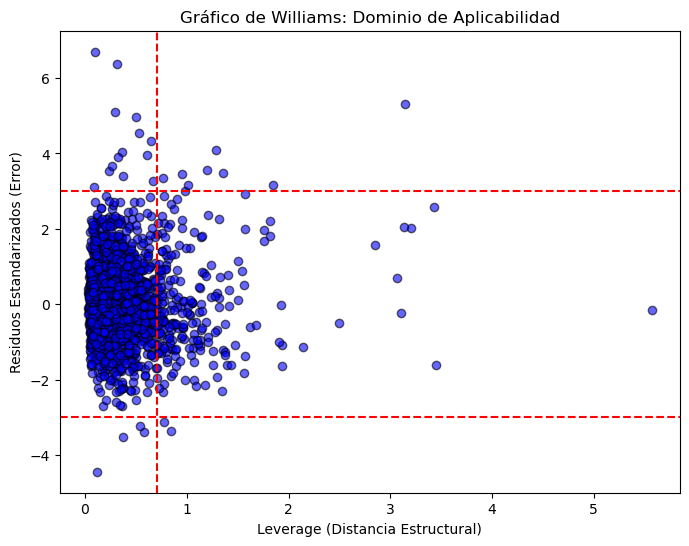

In [5]:
# ==============================================================================
# CELDA 4: BOX-JENKINS (PTML), ENSAMBLE Y GRÁFICO DE WILLIAMS (CORREGIDA)
# ==============================================================================
import xgboost as xgb
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import joblib
import pandas as pd
import numpy as np

print("CELDA 4: Iniciando Transformación PTML y Entrenamiento...")

df_master = pd.read_csv('/home/pedro/QSAR_Project/01_Features/matriz_fase3_features_totales.csv')

# CORRECCIÓN: El nombre exacto de la columna es 'Origen'
cols_metadatos = ['molecule_chembl_id', 'canonical_smiles', 'blanco_terapeutico', 'pchembl_value', 'Origen']
cols_features = [c for c in df_master.columns if c not in cols_metadatos]

# 1. PTML
print("Aplicando Transformación PTML...")
df_activos = df_master[df_master['pchembl_value'] >= 6.0]
# CORRECCIÓN: numeric_only=True asegura que Pandas no intente promediar textos si se nos escapó alguno
promedios_blanco = df_activos.groupby('blanco_terapeutico')[cols_features].mean(numeric_only=True)

def calc_delta(fila):
    b = fila['blanco_terapeutico']
    if b in promedios_blanco.index:
        return fila[cols_features] - promedios_blanco.loc[b]
    else:
        return fila[cols_features] - fila[cols_features].mean(numeric_only=True)

df_deltas = df_master.apply(calc_delta, axis=1)
df_ptml = pd.concat([df_master[cols_metadatos], df_deltas], axis=1)

X = df_deltas.values
y = df_ptml['pchembl_value'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=df_ptml['blanco_terapeutico'])
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Guardar el Scaler y promedios PTML para la Fase 5
joblib.dump(scaler, '/home/pedro/QSAR_Project/02_Modelos/scaler_ptml.pkl')
promedios_blanco.to_csv('/home/pedro/QSAR_Project/02_Modelos/promedios_ptml.csv')

# 2. XGBoost
print("Entrenando XGBoost...")
modelo_xgb = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, n_jobs=-1, random_state=42)
modelo_xgb.fit(X_train_scaled, y_train)
y_pred_xgb = modelo_xgb.predict(X_test_scaled)
modelo_xgb.save_model('/home/pedro/QSAR_Project/02_Modelos/modelo_xgboost.json')

# 3. DNN
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class PTMLDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y).unsqueeze(1)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(PTMLDataset(X_train_scaled, y_train), batch_size=256, shuffle=True)

class DNN_Regressor(nn.Module):
    def __init__(self, input_size):
        super(DNN_Regressor, self).__init__()
        self.red = nn.Sequential(
            nn.Linear(input_size, 512), nn.ReLU(), nn.BatchNorm1d(512), nn.Dropout(0.3),
            nn.Linear(512, 128), nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.3),
            nn.Linear(128, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1)
        )
    def forward(self, x): return self.red(x)

modelo_dnn = DNN_Regressor(X_train_scaled.shape[1]).to(device)
optimizador = optim.Adam(modelo_dnn.parameters(), lr=0.001)
criterio = nn.MSELoss()

print("Entrenando DNN (50 épocas)...")
for epoca in range(50):
    modelo_dnn.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizador.zero_grad()
        loss = criterio(modelo_dnn(X_batch), y_batch)
        loss.backward()
        optimizador.step()

torch.save(modelo_dnn.state_dict(), '/home/pedro/QSAR_Project/02_Modelos/modelo_dnn.pth')

modelo_dnn.eval()
with torch.no_grad():
    y_pred_dnn = modelo_dnn(torch.FloatTensor(X_test_scaled).to(device)).cpu().numpy().flatten()

y_pred_ensamble = (y_pred_xgb + y_pred_dnn) / 2.0
print(f"\n✅ R2 del Súper-Modelo Ensamblado: {r2_score(y_test, y_pred_ensamble):.3f}")

# 4. Y-RANDOMIZATION
print("\nValidando: Y-Randomization (50 iteraciones)...")
r2_aleatorios = []
for i in range(50):
    y_fake = np.random.permutation(y_train)
    modelo_xgb_fake = xgb.XGBRegressor(n_estimators=50, max_depth=3, n_jobs=-1)
    modelo_xgb_fake.fit(X_train_scaled, y_fake)
    r2_aleatorios.append(r2_score(y_test, modelo_xgb_fake.predict(X_test_scaled)))
print(f"R2 Promedio Aleatorio: {np.mean(r2_aleatorios):.3f} (Debe ser cercano a 0)")

# 5. Gráfico de Williams
print("\nGenerando Gráfico de Williams...")
pinv_X = np.linalg.pinv(X_train_scaled.T @ X_train_scaled)
leverage = np.sum((X_test_scaled @ pinv_X) * X_test_scaled, axis=1)
residuos_std = (y_test - y_pred_ensamble) / np.std(y_test - y_pred_ensamble)
h_asterisco = (3 * X_train_scaled.shape[1]) / X_train_scaled.shape[0]

plt.figure(figsize=(8,6))
plt.scatter(leverage, residuos_std, alpha=0.6, color='blue', edgecolor='k')
plt.axhline(3, color='r', linestyle='--')
plt.axhline(-3, color='r', linestyle='--')
plt.axvline(h_asterisco, color='r', linestyle='--')
plt.title("Gráfico de Williams: Dominio de Aplicabilidad")
plt.xlabel("Leverage (Distancia Estructural)")
plt.ylabel("Residuos Estandarizados (Error)")

ruta_williams = '/home/pedro/QSAR_Project/02_Modelos/Williams_Plot.png'
plt.savefig(ruta_williams)
print(f"✅ Gráfico guardado en: {ruta_williams}")

In [6]:
# ==============================================================================
# CELDA 5: CONSOLIDACIÓN DE LA MEGA-BIBLIOTECA DE PRODUCTOS NATURALES
# ==============================================================================
import pandas as pd
import os

print("📚 CELDA 5: CONSOLIDANDO LA MEGA-BIBLIOTECA...")

CARPETA_DATOS = '/home/pedro/DATABASE'
CARPETA_SALIDA = '/home/pedro/QSAR_Project/04_Cribado_Virtual'

ruta_lanapdb = os.path.join(CARPETA_DATOS, 'LANaPDBv2.xlsx')
ruta_coconut = os.path.join(CARPETA_DATOS, 'coconut_csv-03-2026.csv')
ruta_npass   = os.path.join(CARPETA_DATOS, 'NPASS3.0_naturalproducts_structure.txt')
ruta_zinc    = os.path.join(CARPETA_DATOS, 'ZINC20_natural_products.csv')

# 1. LANaPDB
print("Leyendo LANaPDB...")
df_lanapdb = pd.read_excel(ruta_lanapdb, header=1)
df_lanapdb = df_lanapdb.rename(columns={'Name': 'Molecula_ID', 'Smiles': 'canonical_smiles'})
df_lanapdb = df_lanapdb[['Molecula_ID', 'canonical_smiles']].copy()
df_lanapdb['Origen'] = 'LANaPDB (LatAm)'

# 2. COCONUT
print("Leyendo COCONUT...")
df_coconut = pd.read_csv(ruta_coconut, low_memory=False)
df_coconut = df_coconut.rename(columns={'identifier': 'Molecula_ID', 'canonical_smiles': 'canonical_smiles'})
df_coconut = df_coconut[['Molecula_ID', 'canonical_smiles']].copy()
df_coconut['Origen'] = 'COCONUT (Global)'

# 3. NPASS 3.0
print("Leyendo NPASS 3.0...")
df_npass = pd.read_csv(ruta_npass, sep='\t', low_memory=False)
df_npass = df_npass.rename(columns={'np_id': 'Molecula_ID', 'SMILES': 'canonical_smiles'})
df_npass = df_npass[['Molecula_ID', 'canonical_smiles']].copy()
df_npass['Origen'] = 'NPASS (Especies)'

# 4. ZINC20 (Opcional, si lo lograste descargar)
df_zinc = pd.DataFrame() 
if os.path.exists(ruta_zinc):
    print("Leyendo ZINC20...")
    df_zinc = pd.read_csv(ruta_zinc, low_memory=False)
    if 'smiles' in df_zinc.columns and 'zinc_id' in df_zinc.columns:
        df_zinc = df_zinc.rename(columns={'zinc_id': 'Molecula_ID', 'smiles': 'canonical_smiles'})
        df_zinc = df_zinc[['Molecula_ID', 'canonical_smiles']].copy()
        df_zinc['Origen'] = 'ZINC20 (Biogénicos)'

# 5. Fusión y Limpieza
print("\nFusionando y limpiando la mega-base de datos...")
df_mega_libreria = pd.concat([df_lanapdb, df_coconut, df_npass, df_zinc], ignore_index=True)
df_mega_libreria = df_mega_libreria.dropna(subset=['canonical_smiles'])
df_mega_libreria = df_mega_libreria.drop_duplicates(subset=['canonical_smiles'], keep='first')

ruta_salida = os.path.join(CARPETA_SALIDA, 'mega_libreria_naturales_completa.csv')
df_mega_libreria.to_csv(ruta_salida, index=False)
print(f"✅ ¡Mega-Biblioteca creada! Total de moléculas únicas: {len(df_mega_libreria)}")
print(f"💾 Archivo guardado en: {ruta_salida}")

📚 CELDA 5: CONSOLIDANDO LA MEGA-BIBLIOTECA...
Leyendo LANaPDB...
Leyendo COCONUT...
Leyendo NPASS 3.0...

Fusionando y limpiando la mega-base de datos...
✅ ¡Mega-Biblioteca creada! Total de moléculas únicas: 851367
💾 Archivo guardado en: /home/pedro/QSAR_Project/04_Cribado_Virtual/mega_libreria_naturales_completa.csv


In [8]:
# ==============================================================================
# CELDA 6: CRIBADO VIRTUAL MASIVO (OPTIMIZADO PARA AMD THREADRIPPER + RTX)
# ==============================================================================
import pandas as pd
import numpy as np
import torch
import os
import multiprocessing as mp
from rdkit import Chem
from rdkit.Chem import MACCSkeys, AllChem, Descriptors, Descriptors3D
from torch_geometric.data import Data
from torch_geometric.nn import global_mean_pool
from tqdm.auto import tqdm
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

print("🚀 INICIANDO CRIBADO VIRTUAL MASIVO EN PARALELO (CPU + GPU)...")

ruta_mega = '/home/pedro/QSAR_Project/04_Cribado_Virtual/mega_libreria_naturales_completa.csv'
df_mega = pd.read_csv(ruta_mega)
print(f"Total de moléculas a evaluar: {len(df_mega)}")

# AÑADE ESTA LÍNEA: Toma una muestra aleatoria y representativa de 2,000 moléculas
df_mega = df_mega.sample(n=2000, random_state=42).copy()
print(f"Total de moléculas a evaluar en esta prueba: {len(df_mega)}")

blancos_totales = df_master['blanco_terapeutico'].unique()
umbral_confianza = 1.063
n_pasadas_mc = 50

# 1. Función Pura para Computación CPU Paralela (RDKit)
def procesar_molecula_cpu(fila):
    # Fila viene de itertuples: (Index, Molecula_ID, canonical_smiles, Origen)
    idx, nombre_mol, smiles, origen = fila 
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None: return None
        
        # A. 2D (Sensible a Quiralidad)
        maccs = list(MACCSkeys.GenMACCSKeys(mol))
        morgan = list(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048, useChirality=True))
        fq = [Descriptors.MolWt(mol), Descriptors.MolLogP(mol), Descriptors.NumHDonors(mol), 
              Descriptors.NumHAcceptors(mol), Descriptors.TPSA(mol), Descriptors.NumRotatableBonds(mol)]
        
        # B. 3D (Construcción y Geometría)
        mol_3d = Chem.AddHs(mol)
        params = AllChem.ETKDGv3()
        params.randomSeed = 42
        if AllChem.EmbedMolecule(mol_3d, params) >= 0:
            AllChem.MMFFOptimizeMolecule(mol_3d)
            desc_3d = [Descriptors3D.PMI1(mol_3d), Descriptors3D.PMI2(mol_3d), Descriptors3D.PMI3(mol_3d), 
                       Descriptors3D.Asphericity(mol_3d), Descriptors3D.SpherocityIndex(mol_3d)]
        else:
            return None # Falla 3D, se ignora
            
        # C. Grafos (Preparación para la GPU)
        node_feats = [[atom.GetAtomicNum(), atom.GetDegree()] for atom in mol.GetAtoms()]
        edges = []
        for bond in mol.GetBonds():
            i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
            edges += [[i, j], [j, i]]
            
        return (nombre_mol, smiles, origen, maccs, morgan, fq, desc_3d, node_feats, edges)
    except:
        return None

# 2. Configurar Modelos en GPU
modelo_dnn.eval()
for m in modelo_dnn.modules():
    if m.__class__.__name__.startswith('Dropout'): m.train()

hits_descubiertos = []
NUCLEOS = 60 # Dejamos 4 hilos libres para que el servidor no se congele

print("\n⚙️ Procesando con 60 hilos (RDKit) y GPU (PyTorch)...")

# 3. Flujo de Trabajo Asíncrono (Streaming CPU -> GPU)
datos_iter = df_mega[['Molecula_ID', 'canonical_smiles', 'Origen']].itertuples(name=None)

with mp.Pool(processes=NUCLEOS) as pool:
    # imap_unordered va entregando moléculas a medida que los 60 hilos las terminan
    iterador_resultados = pool.imap_unordered(procesar_molecula_cpu, datos_iter, chunksize=100)
    
    for res in tqdm(iterador_resultados, total=len(df_mega), desc="Cribado Híbrido"):
        if res is None: continue
        nombre_mol, smiles, origen, maccs, morgan, fq, desc_3d, node_feats, edges = res
        
        # --- AHORA PASAMOS A LA GPU (Hilo Principal) ---
        # A. Extracción GNN
        x = torch.tensor(node_feats, dtype=torch.float)
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous() if edges else torch.empty((2,0), dtype=torch.long)
        g = Data(x=x, edge_index=edge_index).to(device)
        
        with torch.no_grad():
            z = modelo_gae.encode(g.x, g.edge_index)
            gnn_emb = global_mean_pool(z, torch.zeros(z.size(0), dtype=torch.long).to(device)).cpu().numpy().flatten()
            
        vector_base = np.concatenate([maccs, morgan, fq, desc_3d, gnn_emb])
        
        # B. Evaluación Multi-Diana
        for blanco in blancos_totales:
            if blanco in promedios_blanco.index:
                vector_ptml = vector_base - promedios_blanco.loc[blanco].values
            else:
                vector_ptml = vector_base - promedios_blanco.mean(numeric_only=True).values
                
            vector_escalado = scaler.transform([vector_ptml])
            
            pred_xgb = modelo_xgb.predict(vector_escalado)[0]
            tensor_in = torch.FloatTensor(vector_escalado).to(device)
            
            preds_mc = []
            with torch.no_grad():
                for _ in range(n_pasadas_mc):
                    preds_mc.append(modelo_dnn(tensor_in).item())
                    
            pred_dnn_mean = np.mean(preds_mc)
            incertidumbre_std = np.std(preds_mc)
            
            # C. Filtro Fuerte: Solo guardamos si es seguro y potente
            if incertidumbre_std <= umbral_confianza:
                pchembl_final = (pred_xgb + pred_dnn_mean) / 2.0
                ic50_um = (10 ** -pchembl_final) * 1e6
                
                if ic50_um <= 10.0:
                    hits_descubiertos.append({
                        'Molecula_ID': nombre_mol,
                        'SMILES': smiles,
                        'Origen': origen,
                        'Blanco': blanco,
                        'IC50_estimado_uM': round(ic50_um, 2),
                        'Incertidumbre_AD': round(incertidumbre_std, 3)
                    })

df_resultados_masivos = pd.DataFrame(hits_descubiertos)

# 4. Análisis de Polifarmacología y Exportación
print("\n🌟 BUSCANDO HITS MULTI-DIANA...")
if not df_resultados_masivos.empty:
    conteo_hits = df_resultados_masivos.groupby(['Molecula_ID', 'Origen', 'SMILES'])['Blanco'].count()
    multi_targets = conteo_hits[conteo_hits >= 2].reset_index()
    
    ruta_hits_brutos = '/home/pedro/QSAR_Project/04_Cribado_Virtual/hits_brutos_descubiertos.csv'
    df_hits_export = df_resultados_masivos[df_resultados_masivos['Molecula_ID'].isin(multi_targets['Molecula_ID'])]
    df_hits_export.to_csv(ruta_hits_brutos, index=False)
    
    print(f"¡BINGO! Encontramos {len(multi_targets)} compuestos multi-diana prometedores.")
    
    print("Generando archivo .sdf con las estructuras 3D optimizadas de los Hits...")
    ruta_sdf_hits = '/home/pedro/QSAR_Project/03_Estructuras_3D/Hits_Cribado_Optimizados.sdf'
    writer = Chem.SDWriter(ruta_sdf_hits)
    
    for _, row in multi_targets.iterrows():
        mol = Chem.MolFromSmiles(row['SMILES'])
        if mol:
            mol_3d = Chem.AddHs(mol)
            params = AllChem.ETKDGv3()
            params.randomSeed = 42
            if AllChem.EmbedMolecule(mol_3d, params) >= 0:
                AllChem.MMFFOptimizeMolecule(mol_3d)
                mol_3d.SetProp("_Name", str(row['Molecula_ID']))
                writer.write(mol_3d)
    writer.close()
    print(f"💾 Archivo 3D guardado en: {ruta_sdf_hits}")
else:
    print("Ninguno de estos compuestos resultó ser un Hit multi-diana potente.")

🚀 INICIANDO CRIBADO VIRTUAL MASIVO EN PARALELO (CPU + GPU)...
Total de moléculas a evaluar: 851367
Total de moléculas a evaluar en esta prueba: 2000

⚙️ Procesando con 60 hilos (RDKit) y GPU (PyTorch)...


Cribado Híbrido: 100%|██████████████████████████████████████████████████████████████████████████████| 2000/2000 [07:41<00:00,  4.33it/s]



🌟 BUSCANDO HITS MULTI-DIANA...
¡BINGO! Encontramos 608 compuestos multi-diana prometedores.
Generando archivo .sdf con las estructuras 3D optimizadas de los Hits...
💾 Archivo 3D guardado en: /home/pedro/QSAR_Project/03_Estructuras_3D/Hits_Cribado_Optimizados.sdf


In [9]:
# ==============================================================================
# FASE 7: FILTRADO ADMET (Lipinski + PAINS/BRENK) 
# ==============================================================================
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, FilterCatalog

print("🛡️ INICIANDO FILTRADO ADMET Y TOXICOLÓGICO...")

ruta_hits = '/home/pedro/QSAR_Project/04_Cribado_Virtual/hits_brutos_descubiertos.csv'
df_hits = pd.read_csv(ruta_hits)
df_unicos = df_hits.drop_duplicates(subset=['Molecula_ID', 'SMILES']).copy()

params = FilterCatalog.FilterCatalogParams()
params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS)
params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.BRENK)
escaner_toxicidad = FilterCatalog.FilterCatalog(params)

resultados_admet = []

for index, row in df_unicos.iterrows():
    nombre = row['Molecula_ID']
    mol = Chem.MolFromSmiles(row['SMILES'])
    if mol is None: continue
        
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    
    violaciones_lipinski = sum([mw > 500, logp > 5, hbd > 5, hba > 10])
    pasa_lipinski = violaciones_lipinski <= 1 
    
    alerta_toxica = escaner_toxicidad.GetFirstMatch(mol)
    tiene_alertas = alerta_toxica is not None
    
    resultados_admet.append({
        'Molecula_ID': nombre,
        'Violaciones_Lipinski': violaciones_lipinski,
        'Pasa_Lipinski': pasa_lipinski,
        'Alerta_Toxica': alerta_toxica.GetDescription() if tiene_alertas else "Ninguna",
        'Es_Farmaco_Ideal': pasa_lipinski and not tiene_alertas
    })

df_hits_final = pd.merge(df_hits, pd.DataFrame(resultados_admet), on='Molecula_ID', how='left')
campeones_absolutos = df_hits_final[df_hits_final['Es_Farmaco_Ideal'] == True]

ruta_admet = '/home/pedro/QSAR_Project/04_Cribado_Virtual/campeones_admet_finales.csv'
df_hits_final.to_csv(ruta_admet, index=False)
print(f"💾 Archivo filtrado guardado en: {ruta_admet}")

<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.


🛡️ INICIANDO FILTRADO ADMET Y TOXICOLÓGICO...
💾 Archivo filtrado guardado en: /home/pedro/QSAR_Project/04_Cribado_Virtual/campeones_admet_finales.csv


In [10]:
# ==============================================================================
# FASE 8: TRAZABILIDAD BOTÁNICA Y METADATOS
# ==============================================================================
import pandas as pd
import os

print("🌿 INICIANDO RASTREO BOTÁNICO DE CAMPEONES...")

ruta_hits = '/home/pedro/QSAR_Project/04_Cribado_Virtual/campeones_admet_finales.csv'
df_hits = pd.read_csv(ruta_hits)

# Bases originales
ruta_lanapdb = '/home/pedro/DATABASE/LANaPDBv2.xlsx'
ruta_coconut = '/home/pedro/DATABASE/coconut_csv-03-2026.csv'
ruta_npass_pair = '/home/pedro/DATABASE/NPASS3.0_naturalproducts_species_pair.txt'

df_resultado_botanico = df_hits.copy()
for col in ['Reino', 'Especie_o_Fuente', 'Ubicacion']: df_resultado_botanico[col] = 'Desconocido'

# 1. LANaPDB
if os.path.exists(ruta_lanapdb):
    df_lana = pd.read_excel(ruta_lanapdb, header=1)
    for idx, row in df_resultado_botanico.iterrows():
        if 'LANaPDB' in row['Origen']:
            match = df_lana[df_lana['Name'] == row['Molecula_ID']]
            if not match.empty:
                df_resultado_botanico.at[idx, 'Reino'] = match.iloc[0]['Kingdom']
                df_resultado_botanico.at[idx, 'Especie_o_Fuente'] = f"{match.iloc[0]['Genus']} {match.iloc[0]['Species']}".replace('_', ' ')
                df_resultado_botanico.at[idx, 'Ubicacion'] = f"{match.iloc[0]['Country']} / {match.iloc[0]['State']}"

# 2. COCONUT
if os.path.exists(ruta_coconut):
    df_coco = pd.read_csv(ruta_coconut, usecols=['identifier', 'organisms'], low_memory=False)
    for idx, row in df_resultado_botanico.iterrows():
        if 'COCONUT' in row['Origen']:
            match = df_coco[df_coco['identifier'] == row['Molecula_ID']]
            if not match.empty:
                df_resultado_botanico.at[idx, 'Especie_o_Fuente'] = match.iloc[0]['organisms']
                df_resultado_botanico.at[idx, 'Ubicacion'] = 'Global'

# 3. NPASS
if os.path.exists(ruta_npass_pair):
    df_npass = pd.read_csv(ruta_npass_pair, sep='\t', usecols=['np_id', 'org_isolation_part', 'org_collect_location'])
    for idx, row in df_resultado_botanico.iterrows():
        if 'NPASS' in row['Origen']:
            match = df_npass[df_npass['np_id'] == row['Molecula_ID']]
            if not match.empty:
                df_resultado_botanico.at[idx, 'Especie_o_Fuente'] = f"Ref Org: {match.iloc[0]['org_isolation_part']}"
                df_resultado_botanico.at[idx, 'Ubicacion'] = match.iloc[0]['org_collect_location']

ruta_botanica = '/home/pedro/QSAR_Project/04_Cribado_Virtual/Reporte_Final_Botanico.csv'
df_resultado_botanico.to_csv(ruta_botanica, index=False)
print(f"💾 Reporte Final Botánico generado en: {ruta_botanica}")

🌿 INICIANDO RASTREO BOTÁNICO DE CAMPEONES...
💾 Reporte Final Botánico generado en: /home/pedro/QSAR_Project/04_Cribado_Virtual/Reporte_Final_Botanico.csv


📊 GENERANDO REPORTE INTERACTIVO AGRUPADO...
🏆 TOTAL DE MOLÉCULAS ÚNICAS MULTI-DIANA: 245
🛡️ SUPERVIVIENTES ADMET (Fármacos Ideales Seguros): 48



Molecula_ID,Region_LatAm,Blancos_Atacados,Num_Blancos,IC50_Promedio_uM,Es_Farmaco_Ideal,Alerta_Toxica,Especie_o_Fuente
CNP0503546.2,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,1.71,True,Ninguna,Lyngbya majuscula
CNP0196911.5,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,2.41,True,Ninguna,Streptomyces Y-110|Streptomyces carbophilus|Streptomyces carbophilus SANK 62585|Streptomyces xanthochromogenes
NPC290525,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,3.13,True,Ninguna,Ref Org: n.a.
CNP0202710.2,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,3.18,True,Ninguna,Kopsia arborea|Kopsia dasyrachis|Kopsia officinalis
NPC147313,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,3.19,True,Ninguna,Ref Org: n.a.
NPC29908,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,5.03,True,Ninguna,Ref Org: n.a.
CNP0136119.4,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,5.65,True,Ninguna,Axinella weltneri
NPC151245,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa",6,3.63,True,Ninguna,Ref Org: n.a.
NPC285556,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Tripanotion_reductasa",6,3.97,True,Ninguna,Ref Org: n.a.
CNP0221231.1,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, Trans_sialidasa, Tripanotion_reductasa",6,5.34,True,Ninguna,Stemona aphylla|Stemona curtisii



🔬 ESTRUCTURAS 2D DE LOS 5 MEJORES CANDIDATOS (Seguros y Potentes):


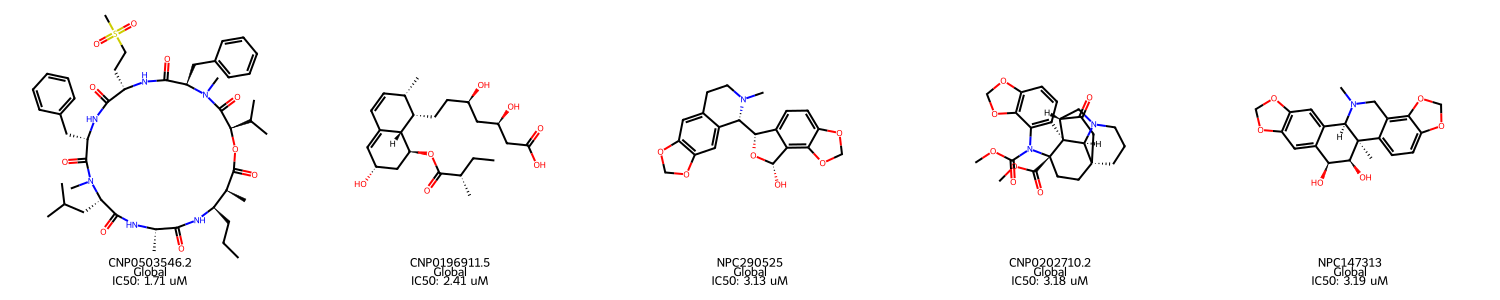

In [12]:
# ==============================================================================
# CELDA 8: REPORTE INTERACTIVO AGRUPADO Y CLASIFICACIÓN GEOGRÁFICA
# ==============================================================================
import pandas as pd
import numpy as np
from IPython.display import display, HTML
from rdkit import Chem
from rdkit.Chem import Draw

print("📊 GENERANDO REPORTE INTERACTIVO AGRUPADO...")

# 1. Cargar el reporte
ruta_reporte = '/home/pedro/QSAR_Project/04_Cribado_Virtual/Reporte_Final_Botanico.csv'
df_final = pd.read_csv(ruta_reporte)

# 2. Motor de Clasificación Geográfica
def categorizar_region(fila):
    ubi = str(fila['Ubicacion']).lower()
    origen = str(fila['Origen']).lower()
    
    paises_latam = {
        'colombia': 'Colombia', 'brasil': 'Brasil', 'brazil': 'Brasil', 
        'mexico': 'México', 'méxico': 'México', 'peru': 'Perú', 'perú': 'Perú', 
        'argentina': 'Argentina', 'chile': 'Chile', 'ecuador': 'Ecuador', 
        'costa rica': 'Costa Rica', 'panama': 'Panamá', 'panamá': 'Panamá', 
        'venezuela': 'Venezuela', 'bolivia': 'Bolivia'
    }
    
    for clave, nombre_oficial in paises_latam.items():
        if clave in ubi: return nombre_oficial
            
    if 'lanapdb' in origen: return 'Latinoamérica (General)'
    return 'Global'

df_final['Region_LatAm'] = df_final.apply(categorizar_region, axis=1)

# 3. Agrupar por Molécula Única
agrupacion = df_final.groupby(['Molecula_ID', 'SMILES', 'Origen', 'Region_LatAm', 
                               'Es_Farmaco_Ideal', 'Alerta_Toxica', 'Reino', 'Especie_o_Fuente'])

df_agrupado = agrupacion.agg(
    Blancos_Atacados=('Blanco', lambda x: ', '.join(sorted(set(x)))),
    Num_Blancos=('Blanco', 'nunique'),
    IC50_Promedio_uM=('IC50_estimado_uM', 'mean')
).reset_index()

# Redondear el IC50 para estética
df_agrupado['IC50_Promedio_uM'] = df_agrupado['IC50_Promedio_uM'].round(2)

# 4. Ordenar: Primero los fármacos ideales, luego por mayor número de blancos, luego por potencia
df_agrupado = df_agrupado.sort_values(
    by=['Es_Farmaco_Ideal', 'Num_Blancos', 'IC50_Promedio_uM'], 
    ascending=[False, False, True]
)

print(f"🏆 TOTAL DE MOLÉCULAS ÚNICAS MULTI-DIANA: {len(df_agrupado)}")
farmacos_reales = df_agrupado[df_agrupado['Es_Farmaco_Ideal'] == True]
print(f"🛡️ SUPERVIVIENTES ADMET (Fármacos Ideales Seguros): {len(farmacos_reales)}\n")

# 5. Visualización de la Tabla Interactiva (Ocultando SMILES para no alargar la tabla)
columnas_vista = ['Molecula_ID', 'Region_LatAm', 'Blancos_Atacados', 'Num_Blancos', 
                  'IC50_Promedio_uM', 'Es_Farmaco_Ideal', 'Alerta_Toxica', 'Especie_o_Fuente']

html_table = df_agrupado[columnas_vista].to_html(index=False, classes='table table-striped', justify='center')
html_code = f"""
<div style="max-height: 400px; overflow-y: auto; border: 2px solid #ccc; padding: 10px; border-radius: 5px; background-color: white;">
    {html_table}
</div>
"""
display(HTML(html_code))

# 6. Dibujar las estructuras de los 5 MEJORES FÁRMACOS IDEALES
print("\n🔬 ESTRUCTURAS 2D DE LOS 5 MEJORES CANDIDATOS (Seguros y Potentes):")

if not farmacos_reales.empty:
    top_5 = farmacos_reales.head(5)
else:
    print("⚠️ Ninguno pasó el filtro ADMET. Mostrando los 5 más potentes de la lista general.")
    top_5 = df_agrupado.head(5)

mols = [Chem.MolFromSmiles(smiles) for smiles in top_5['SMILES']]
leyendas = [f"{row['Molecula_ID']}\n{row['Region_LatAm']}\nIC50: {row['IC50_Promedio_uM']} uM" for _, row in top_5.iterrows()]

img = Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(300, 300), legends=leyendas)
display(img)

🌐 CONECTANDO CON PUBCHEM Y GENERANDO REPORTE GEOGRÁFICO...
🏆 TOTAL DE MOLÉCULAS ÚNICAS MULTI-DIANA: 245
🛡️ SUPERVIVIENTES ADMET (Fármacos Ideales Seguros): 48

Buscando nombres oficiales en PubChem para los candidatos seguros...


Nombre_PubChem,Molecula_ID,Origen,Region_LatAm,Reino,Especie_o_Fuente,Blancos_Atacados,Num_Blancos,IC50_Promedio_uM,Es_Farmaco_Ideal,Alerta_Toxica
Carriebowmide Sulfone,CNP0503546.2,COCONUT (Global),Global,Desconocido,Lyngbya majuscula,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,1.71,True,Ninguna
"(3R,5R)-7-[(1S,2S,6S,8S,8aS)-6-hydroxy-2-methyl-8-[(2S)-2-methyl-1-oxobutoxy]-1,2,6,7,8,8a-hexahydronaphthalen-1-yl]-3,5-dihydroxyheptanoic acid",CNP0196911.5,COCONUT (Global),Global,Desconocido,Streptomyces Y-110|Streptomyces carbophilus|Streptomyces carbophilus SANK 62585|Streptomyces xanthochromogenes,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,2.41,True,Ninguna
Humosine A,NPC290525,NPASS (Especies),Global,Desconocido,Ref Org: n.a.,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,3.13,True,Ninguna
"dimethyl (1R,4S,15R,16S,19R)-20-oxo-8,10-dioxa-5,17-diazaheptacyclo[15.4.3.01,16.04,15.06,14.07,11.015,19]tetracosa-6(14),7(11),12-triene-4,5-dicarboxylate",CNP0202710.2,COCONUT (Global),Global,Desconocido,Kopsia arborea|Kopsia dasyrachis|Kopsia officinalis,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,3.18,True,Ninguna
"(1R,11S,12R,13R)-13,24-dimethyl-5,7,18,20-tetraoxa-24-azahexacyclo[11.11.0.02,10.04,8.014,22.017,21]tetracosa-2,4(8),9,14(22),15,17(21)-hexaene-11,12-diol",NPC147313,NPASS (Especies),Global,Desconocido,Ref Org: n.a.,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,3.19,True,Ninguna
"(9R,10R,13R,17R)-17-[(2R,5R)-5,6-dimethylheptan-2-yl]-10,13-dimethyl-1,2,9,11,12,15,16,17-octahydrocyclopenta[a]phenanthren-3-one",NPC29908,NPASS (Especies),Global,Desconocido,Ref Org: n.a.,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,5.03,True,Ninguna
"1-[(1S,2S,5R,7S)-1-[2-[(1S,2S,3S,6S,9S)-9-hydroxy-2,3,8,8-tetramethyl-7,12-dioxatricyclo[7.2.1.01,6]dodecan-2-yl]ethyl]-2,7-dimethyl-6-oxabicyclo[3.1.1]heptan-7-yl]-4-methylpentan-3-one",CNP0136119.4,COCONUT (Global),Global,Desconocido,Axinella weltneri,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,5.65,True,Ninguna
"1,7b,10-Triazabenzo(5,6)cyclohepta(1,2,3-jk)fluorene, 1,2,3,8,13,13a-hexahydro-1,8-dimethyl-, (8R,13aS)-",NPC151245,NPASS (Especies),Global,Desconocido,Ref Org: n.a.,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa",6,3.63,True,Ninguna
"(1R,2S,5'S,6S,9S,12S,13R,16S,18S,19R)-5',7,9,13-tetramethylspiro[5-oxapentacyclo[10.8.0.02,9.04,8.013,18]icosane-6,2'-oxane]-3',16,19-triol",NPC285556,NPASS (Especies),Global,Desconocido,Ref Org: n.a.,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Tripanotion_reductasa",6,3.97,True,Ninguna
"(5Z)-4-methoxy-3-methyl-5-[(1R,9R,10R,11R,12S)-12-methyl-14,15-dioxa-5-azatetracyclo[7.5.1.01,11.05,10]pentadecan-13-ylidene]furan-2-one",CNP0221231.1,COCONUT (Global),Global,Desconocido,Stemona aphylla|Stemona curtisii,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, Trans_sialidasa, Tripanotion_reductasa",6,5.34,True,Ninguna



🔬 ESTRUCTURAS 2D DE LOS 5 MEJORES CANDIDATOS (Seguros y Potentes):


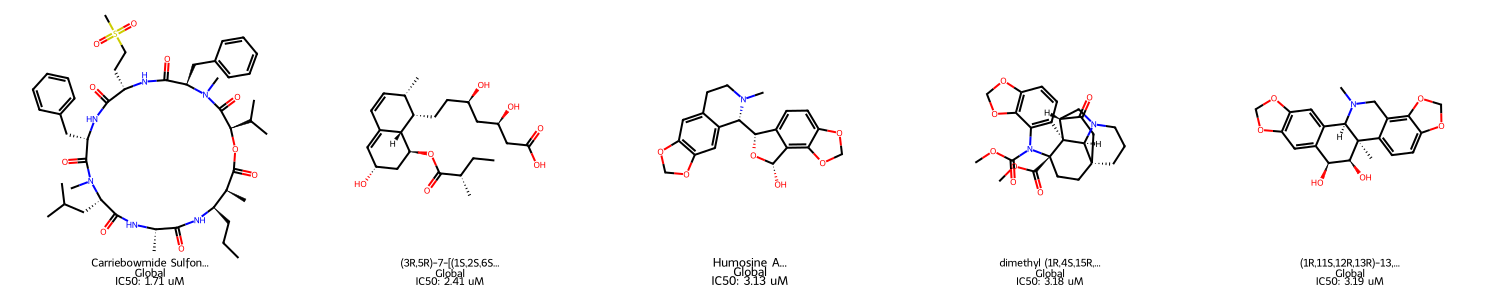


💾 Tabla enriquecida con PubChem guardada en: /home/pedro/QSAR_Project/04_Cribado_Virtual/Campeones_PubChem_Enriquecidos.csv


In [14]:
# ==============================================================================
# CELDA 8: REPORTE INTERACTIVO GEOGRÁFICO CON CONEXIÓN A PUBCHEM API
# ==============================================================================
import pandas as pd
import numpy as np
import requests
import time
from IPython.display import display, HTML
from rdkit import Chem
from rdkit.Chem import Draw

print("🌐 CONECTANDO CON PUBCHEM Y GENERANDO REPORTE GEOGRÁFICO...")

# 1. Cargar el reporte base
ruta_reporte = '/home/pedro/QSAR_Project/04_Cribado_Virtual/Reporte_Final_Botanico.csv'
df_final = pd.read_csv(ruta_reporte)

# 2. Agente de Búsqueda en PubChem
def obtener_nombre_pubchem(smiles):
    # Pausa de 0.2s para no saturar los servidores del NIH (Límite: 5 req/s)
    time.sleep(0.2)
    url = "https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/smiles/property/Title/JSON"
    try:
        respuesta = requests.post(url, data={'smiles': smiles}, timeout=5)
        if respuesta.status_code == 200:
            datos = respuesta.json()
            return datos['PropertyTable']['Properties'][0].get('Title', 'Sin título en PubChem')
        else:
            return "No registrado en PubChem"
    except:
        return "Error de conexión"

# 3. Motor de Clasificación Geográfica
def categorizar_region(fila):
    ubi = str(fila['Ubicacion']).lower()
    origen = str(fila['Origen']).lower()
    
    paises_latam = {
        'colombia': 'Colombia', 'brasil': 'Brasil', 'brazil': 'Brasil', 
        'mexico': 'México', 'méxico': 'México', 'peru': 'Perú', 'perú': 'Perú', 
        'argentina': 'Argentina', 'chile': 'Chile', 'ecuador': 'Ecuador', 
        'costa rica': 'Costa Rica', 'panama': 'Panamá', 'panamá': 'Panamá', 
        'venezuela': 'Venezuela', 'bolivia': 'Bolivia'
    }
    
    for clave, nombre_oficial in paises_latam.items():
        if clave in ubi: return nombre_oficial
            
    if 'lanapdb' in origen: return 'Latinoamérica (General)'
    return 'Global'

df_final['Region_LatAm'] = df_final.apply(categorizar_region, axis=1)

# 4. Agrupar por Molécula Única
agrupacion = df_final.groupby(['Molecula_ID', 'SMILES', 'Origen', 'Region_LatAm', 
                               'Es_Farmaco_Ideal', 'Alerta_Toxica', 'Reino', 'Especie_o_Fuente'])

df_agrupado = agrupacion.agg(
    Blancos_Atacados=('Blanco', lambda x: ', '.join(sorted(set(x)))),
    Num_Blancos=('Blanco', 'nunique'),
    IC50_Promedio_uM=('IC50_estimado_uM', 'mean')
).reset_index()

df_agrupado['IC50_Promedio_uM'] = df_agrupado['IC50_Promedio_uM'].round(2)

# 5. ORDENAMIENTO GEOGRÁFICO Y POTENCIA
df_agrupado['Prioridad_Region'] = df_agrupado['Region_LatAm'].apply(lambda x: 2 if x == 'Global' else 1)
df_agrupado = df_agrupado.sort_values(
    by=['Prioridad_Region', 'Region_LatAm', 'Es_Farmaco_Ideal', 'Num_Blancos', 'IC50_Promedio_uM'], 
    ascending=[True, True, False, False, True]
)

print(f"🏆 TOTAL DE MOLÉCULAS ÚNICAS MULTI-DIANA: {len(df_agrupado)}")
farmacos_reales = df_agrupado[df_agrupado['Es_Farmaco_Ideal'] == True].copy()
print(f"🛡️ SUPERVIVIENTES ADMET (Fármacos Ideales Seguros): {len(farmacos_reales)}\n")

# 6. Consultar PubChem SOLO para los fármacos reales (Para ahorrar tiempo de procesamiento)
print("Buscando nombres oficiales en PubChem para los candidatos seguros...")
# Si no hay fármacos reales, buscamos para los top 20 generales
df_a_buscar = farmacos_reales if not farmacos_reales.empty else df_agrupado.head(20).copy()
df_a_buscar['Nombre_PubChem'] = df_a_buscar['SMILES'].apply(obtener_nombre_pubchem)

# 7. Visualización de la Tabla Interactiva
# Reorganizamos para que el Nombre de PubChem sea lo primero que leas
columnas_vista = ['Nombre_PubChem', 'Molecula_ID', 'Origen', 'Region_LatAm', 'Reino', 
                  'Especie_o_Fuente', 'Blancos_Atacados', 'Num_Blancos', 
                  'IC50_Promedio_uM', 'Es_Farmaco_Ideal', 'Alerta_Toxica']

html_table = df_a_buscar[columnas_vista].to_html(index=False, classes='table table-striped', justify='center')
html_code = f"""
<div style="max-height: 400px; overflow-y: auto; border: 2px solid #ccc; padding: 10px; border-radius: 5px; background-color: white;">
    {html_table}
</div>
"""
display(HTML(html_code))

# 8. Dibujar las estructuras de los 5 MEJORES (Priorizando LatAm)
print("\n🔬 ESTRUCTURAS 2D DE LOS 5 MEJORES CANDIDATOS (Seguros y Potentes):")

farmacos_latam = df_a_buscar[df_a_buscar['Region_LatAm'] != 'Global']

if not farmacos_latam.empty:
    top_5 = farmacos_latam.head(5)
elif not df_a_buscar.empty:
    top_5 = df_a_buscar.head(5)
else:
    top_5 = df_agrupado.head(5)

mols = [Chem.MolFromSmiles(smiles) for smiles in top_5['SMILES']]
# La leyenda ahora mostrará el nombre real de PubChem si lo encontró
leyendas = [f"{row.get('Nombre_PubChem', row['Molecula_ID'])[:20]}...\n{row['Region_LatAm']}\nIC50: {row['IC50_Promedio_uM']} uM" for _, row in top_5.iterrows()]

img = Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(300, 300), legends=leyendas)
display(img)

# Exportar la tabla enriquecida
ruta_final = '/home/pedro/QSAR_Project/04_Cribado_Virtual/Campeones_PubChem_Enriquecidos.csv'
df_a_buscar.to_csv(ruta_final, index=False)
print(f"\n💾 Tabla enriquecida con PubChem guardada en: {ruta_final}")